<a href="https://colab.research.google.com/github/Mainak23/ocr_essentials/blob/main/ocr_version_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Download and install Noto Sans Bengali font

This will download the font file necessary for generating the Bengali characters. It will place `NotoSansBengali-Regular.ttf` into the `fonts/` directory.

In [3]:
# Create the 'fonts' directory if it doesn't exist
!mkdir -p fonts

# Download NotoSansBengali-Regular.ttf directly
# This link points to the raw .ttf file on Google Fonts GitHub repository
!wget -q -nc "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf" -P fonts/

print("NotoSansBengali-Regular.ttf has been downloaded and placed in the 'fonts/' directory.")

NotoSansBengali-Regular.ttf has been downloaded and placed in the 'fonts/' directory.


After running the above cell to download the font, please re-run the cell that generates the images (cell `Qi1UnJXrrN7n`).

In [4]:
from PIL import Image, ImageDraw, ImageFont
import os
from pathlib import Path

# ================== CONFIG ==================
OUTPUT_ROOT = "bengali_dataset"
FONT_PATH = "fonts/NotoSansBengali-Regular.ttf"   # Download a good Bengali font
FONT_SIZE = 120
IMAGE_SIZE = (200, 200)
BG_COLOR = (255, 255, 255)   # White
TEXT_COLOR = (0, 0, 0)       # Black

# Create font directory and download a font if needed
os.makedirs("fonts", exist_ok=True)

# List of characters / juktakhors / words you want
labels = [
    'ক', 'খ', 'গ', 'ঘ', 'ঙ', 'চ', 'ছ', 'জ', 'ঝ', 'ঞ',
    'ট', 'ঠ', 'ড', 'ঢ', 'ণ', 'ত', 'থ', 'দ', 'ধ', 'ন',
    'প', 'ফ', 'ব', 'ভ', 'ম', 'য', 'র', 'ল', 'শ', 'ষ', 'স', 'হ',
    'ড়', 'ঢ়', 'য়', 'ৎ',
    # Juktakhors (examples)
    'ক্ষ', 'ত্ত', 'ত্র', 'দ্ধ', 'ন্ধ', 'ম্ম', 'স্ক', 'স্ত', 'স্প',
    # Words
    'আমি', 'বাংলা', 'বাংলাদেশ', 'জুক্তাক্ষর'
]

# ============================================
Path(OUTPUT_ROOT).mkdir(exist_ok=True)

font = None # Initialize font to None
try:
    font = ImageFont.truetype(FONT_PATH, FONT_SIZE)
except Exception as e: # Catch any exception during font loading
    print(f"Error loading font: {e}")
    print("Font not found! Please download a Bengali font (NotoSansBengali, Kalpurush, Siyam Rupali, etc.)")
    print("and place it in the 'fonts/' folder.")

if font: # Only proceed if font was successfully loaded
    for label in labels:
        class_dir = Path(OUTPUT_ROOT) / label.replace('/', '_')   # safety for words
        class_dir.mkdir(exist_ok=True)

        for i in range(5):   # Generate 5 images per class (you can increase)
            img = Image.new('RGB', IMAGE_SIZE, color=BG_COLOR)
            draw = ImageDraw.Draw(img)

            # Center the text
            bbox = draw.textbbox((0, 0), label, font=font)
            text_width = bbox[2] - bbox[0]
            text_height = bbox[3] - bbox[1]
            x = (IMAGE_SIZE[0] - text_width) // 2
            y = (IMAGE_SIZE[1] - text_height) // 2 - 10

            draw.text((x, y), label, font=font, fill=TEXT_COLOR)

            filename = f"{label}_{i+1:03d}.png"
            img.save(class_dir / filename)

    print(f"✅ Generated images in '{OUTPUT_ROOT}' folder!")
else:
    print("❌ Image generation skipped due to font loading error.")


✅ Generated images in 'bengali_dataset' folder!


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
from pathlib import Path
from typing import Tuple, List, Optional

class BengaliDataset(Dataset):
    def __init__(
        self,
        root_dir: str,
        transform: Optional[transforms.Compose] = None,
        extensions: tuple = ('.png', '.jpg', '.jpeg')
    ):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.extensions = extensions

        self.classes = []
        self.class_to_idx = {}
        self.samples = []        # list of (image_path, class_idx)

        self._make_dataset()

        print(f"✅ Dataset loaded!")
        print(f"   Total images : {len(self.samples)}")
        print(f"   Total classes: {len(self.classes)}")
        # print(f"   Classes: {self.classes}")   # Uncomment if needed

    def _make_dataset(self):
        """Scan folder structure and build samples list"""
        if not self.root_dir.exists():
            raise FileNotFoundError(f"Root directory not found: {self.root_dir}")

        # Get all subfolders (each folder = one class)
        class_dirs = sorted([d for d in self.root_dir.iterdir() if d.is_dir()])

        for idx, class_dir in enumerate(class_dirs):
            class_name = class_dir.name  # This is your label (Bengali character/word)
            self.classes.append(class_name)
            self.class_to_idx[class_name] = idx

            # Get all images in this class folder
            for ext in self.extensions:
                for img_path in class_dir.glob(f"*{ext}"):
                    self.samples.append((str(img_path), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        img_path, label = self.samples[idx]

        # Load image
        image = Image.open(img_path).convert('L')   # or 'L' for grayscale

        if self.transform:
            image = self.transform(image)
        else:
            # Default transform
            image = transforms.ToTensor()(image)

        return image, label

    def get_class_name(self, idx: int) -> str:
        """Get Bengali label from index"""
        return self.classes[idx]

    def show_sample(self, idx: int):
      """Display a sample with its Bengali label"""
      import matplotlib.pyplot as plt
      img, label = self[idx]
      img = img.permute(1, 2, 0).numpy() if img.dim() == 3 else img.squeeze().numpy()

      plt.figure(figsize=(4,4))
      plt.imshow(img, cmap='gray' if img.ndim == 2 else None)
      plt.title(f"Label: {self.classes[label]}", fontsize=16)
      plt.axis('off')
      plt.show()

✅ Dataset loaded!
   Total images : 245
   Total classes: 49


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) D

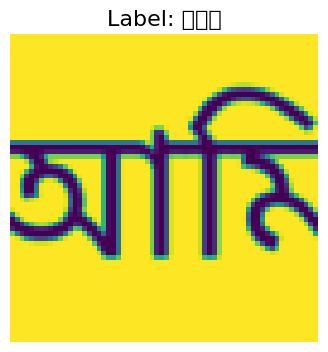

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch shape: torch.Size([32, 1, 64, 64])
Label example: 46 → স্প


In [6]:
# ====================== TRANSFORMS ======================
transform = transforms.Compose([
    transforms.Resize((64, 64)),           # Change size as needed
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485],
                        std=[0.229]),   # ImageNet stats (good default)
])

# ====================== CREATE DATASET ======================
dataset = BengaliDataset(
    root_dir="./bengali_dataset",
    transform=transform
)

# Split into train/test (optional)
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# ====================== DATALOADERS ======================
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, # Changed from test_loader to test_dataset
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

dataset.show_sample(2)
# Test one batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")        # [32, 1, 64, 64]
print(f"Label example: {labels[0].item()} → {dataset.get_class_name(labels[0])}")

In [7]:
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(1, 32, 3), # Input: [batch_size, 1, 64, 64] -> Output after conv: [batch_size, 32, 62, 62]

            nn.ReLU(),

            nn.MaxPool2d(2),    # Output after maxpool: [batch_size, 32, 31, 31]

            nn.Flatten(),       # Output after flatten: [batch_size, 32 * 31 * 31 = 30752]

            nn.Linear(32 * 31 * 31, 49) # Corrected input features (30752) and output classes (49)
        )

    def forward(self, x):

        return self.net(x)

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

for epoch in range(1000):

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print(loss.item())

26.777639389038086
7.469911098480225
1.3726084232330322
0.5268011689186096
0.42500579357147217
0.0013716744724661112
0.026059091091156006
0.023165646940469742
0.0073651522397994995
0.005618817172944546
0.006875683553516865
0.010789655148983002
0.001376371830701828
0.0028385946061462164
0.0014106814051046968
0.0024227811954915524
0.004023877438157797
0.003039965871721506
0.002777145244181156
0.0022400282323360443
0.005095761269330978
0.0017933438066393137
0.00099458871409297
0.0030433880165219307
0.0025346563197672367
0.0015910357469692826
0.001258617965504527
0.003843695390969515
0.0012301336973905563
0.000684583093971014
0.002508047968149185
0.0005173558602109551
0.002419170457869768
0.0009347082232125103
0.0007491267169825733
0.0009511748794466257
0.002649304922670126
0.0005391514860093594
0.0014033238403499126
0.0018532031681388617
0.000820994668174535
0.0007590173627249897
0.00031128423870541155
0.00047880643978714943
0.0017802765360102057
0.0009255966870114207
0.000407535262638703